# Blinkit Delivery Performance Analytics

## Project Objective

Analyze delivery operations to evaluate ETA accuracy, delivery performance, and order fulfillment efficiency across multiple cities. Identify delivery bottlenecks and generate operational insights using Python.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("ggplot")

In [2]:
df = pd.read_csv("MOCK_DATA (3).csv")

df.head()

,order_id,city,order_date,order_time,delivery_partner,distance_km,prep_time_min,estimated_eta_min,actual_delivery_time_min,on_time,cancelled,cancellation_reason,order_value,delivery_fee,customer_rating,payment_method,restaurant_category,weather,peak_hour
0,1,Pune,12/17/2025,8:40 PM,DP045,25.17,56,47,90,True,False,Weather,1387.63,27.10,4.2,UPI,Snacks,Rainy,False
1,2,Lucknow,12/10/2025,5:58 PM,DP016,19.23,2,60,89,True,False,Restaurant,427.76,18.91,3.1,Card,Dairy,Rainy,True
2,3,Chennai,9/21/2025,12:07 AM,DP035,28.55,7,31,54,True,False,Restaurant,338.49,67.11,3.9,UPI,Bakery,Rainy,False
3,4,Mumbai,11/2/2025,2:50 PM,DP035,19.54,6,56,23,True,True,Customer,685.41,40.02,3.0,Card,Bakery,Clear,True
4,5,Chennai,4/17/2025,8:29 AM,DP047,15.22,55,53,35,False,True,Restaurant,105.65,54.54,2.2,UPI,Pharmacy,Rainy,True


In [3]:
df.shape

(1000, 19)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   order_id                  1000 non-null   int64  
 1   city                      1000 non-null   object 
 2   order_date                1000 non-null   object 
 3   order_time                1000 non-null   object 
 4   delivery_partner          1000 non-null   object 
 5   distance_km               1000 non-null   float64
 6   prep_time_min             1000 non-null   int64  
 7   estimated_eta_min         1000 non-null   int64  
 8   actual_delivery_time_min  1000 non-null   int64  
 9   on_time                   1000 non-null   bool   
 10  cancelled                 1000 non-null   bool   
 11  cancellation_reason       1000 non-null   object 
 12  order_value               1000 non-null   float64
 13  delivery_fee              1000 non-null   float64
 14  customer_

In [5]:
df.describe()

,order_id,distance_km,prep_time_min,estimated_eta_min,actual_delivery_time_min,order_value,delivery_fee,customer_rating
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,15.349280,29.221000,36.101000,48.916000,806.698750,44.870750,2.998500
std,288.819436,8.367395,17.846362,14.784566,23.448855,400.910464,20.431883,1.155103
min,1.000000,1.060000,0.000000,10.000000,10.000000,104.900000,10.130000,1.000000
25%,250.750000,8.112500,13.000000,24.000000,28.750000,458.665000,26.887500,2.000000
50%,500.500000,15.155000,29.500000,37.000000,47.000000,787.640000,44.845000,3.000000
75%,750.250000,22.762500,44.000000,49.000000,69.000000,1174.032500,62.512500,4.000000
max,1000.000000,29.980000,60.000000,60.000000,90.000000,1499.320000,79.960000,5.000000


In [6]:
df.isnull().sum()

,0
order_id,0
city,0
order_date,0
order_time,0
delivery_partner,0
distance_km,0
prep_time_min,0
estimated_eta_min,0
actual_delivery_time_min,0
on_time,0


In [7]:
df["order_date"] = pd.to_datetime(df["order_date"])

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.columns

Index(['order_id', 'city', 'order_date', 'order_time', 'delivery_partner',
       'distance_km', 'prep_time_min', 'estimated_eta_min',
       'actual_delivery_time_min', 'on_time', 'cancelled',
       'cancellation_reason', 'order_value', 'delivery_fee', 'customer_rating',
       'payment_method', 'restaurant_category', 'weather', 'peak_hour'],
      dtype='object')

In [11]:
total_orders = len(df)

delivered_orders = (~df["cancelled"]).sum()

cancelled_orders = df["cancelled"].sum()

cancellation_rate = (cancelled_orders / total_orders) * 100

on_time_rate = df["on_time"].mean() * 100

avg_eta = df["estimated_eta_min"].mean()

avg_delivery_time = df["actual_delivery_time_min"].mean()

avg_order_value = df["order_value"].mean()

avg_rating = df["customer_rating"].mean()

In [12]:
print(f"Total Orders : {total_orders}")

print(f"Delivered Orders : {delivered_orders}")

print(f"Cancelled Orders : {cancelled_orders}")

print(f"Cancellation Rate : {cancellation_rate:.2f}%")

print(f"On-Time Delivery Rate : {on_time_rate:.2f}%")

print(f"Average ETA : {avg_eta:.2f} minutes")

print(f"Average Delivery Time : {avg_delivery_time:.2f} minutes")

print(f"Average Order Value : ₹{avg_order_value:.2f}")

print(f"Average Customer Rating : {avg_rating:.2f}")

Total Orders : 1000
Delivered Orders : 517
Cancelled Orders : 483
Cancellation Rate : 48.30%
On-Time Delivery Rate : 50.20%
Average ETA : 36.10 minutes
Average Delivery Time : 48.92 minutes
Average Order Value : ₹806.70
Average Customer Rating : 3.00


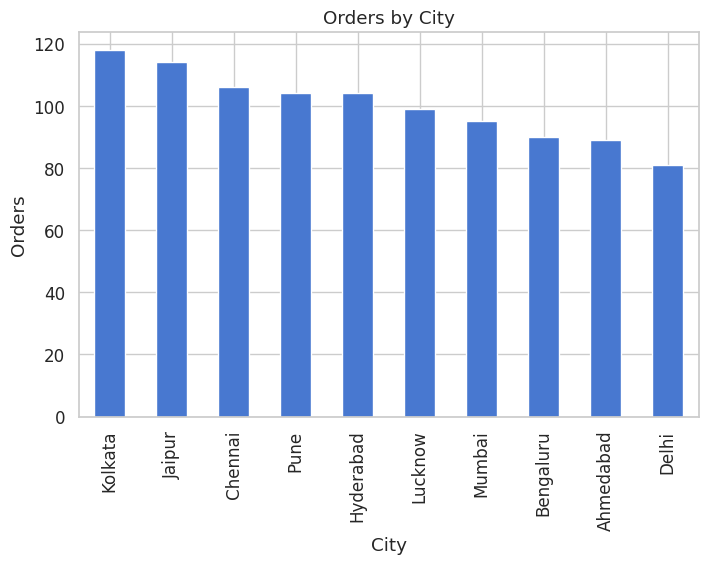

In [24]:
city_orders = df["city"].value_counts()

city_orders.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Orders by City")
plt.xlabel("City")
plt.ylabel("Orders")
plt.show()

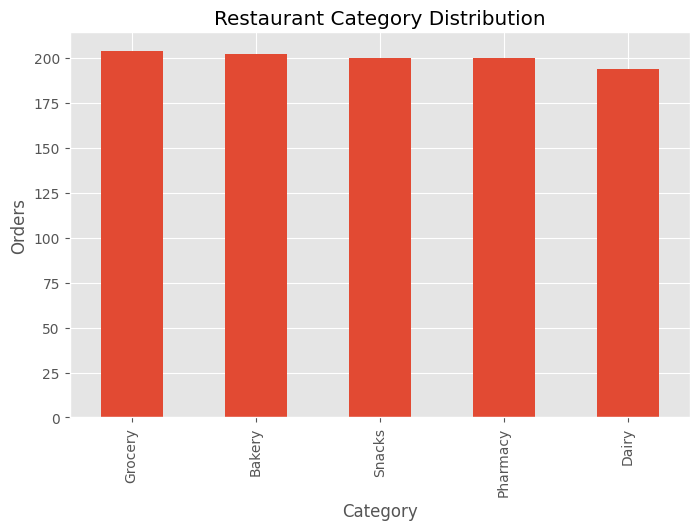

In [14]:
df["restaurant_category"].value_counts().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Restaurant Category Distribution")
plt.xlabel("Category")
plt.ylabel("Orders")
plt.show()

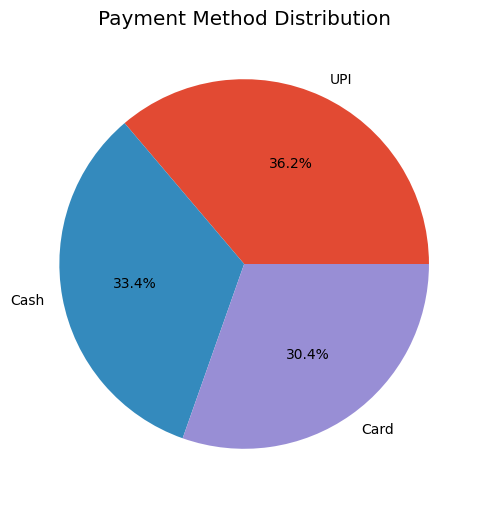

In [15]:
df["payment_method"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6,6)
)

plt.ylabel("")
plt.title("Payment Method Distribution")
plt.show()

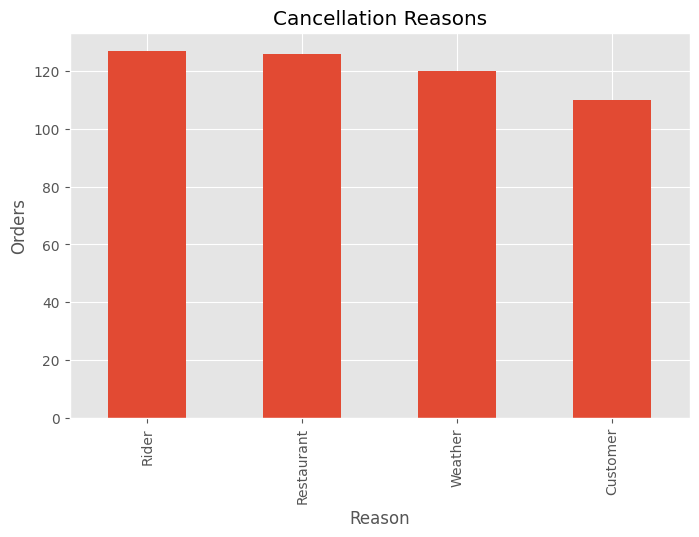

In [16]:
df[df["cancelled"]]["cancellation_reason"].value_counts().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Cancellation Reasons")
plt.xlabel("Reason")
plt.ylabel("Orders")
plt.show()

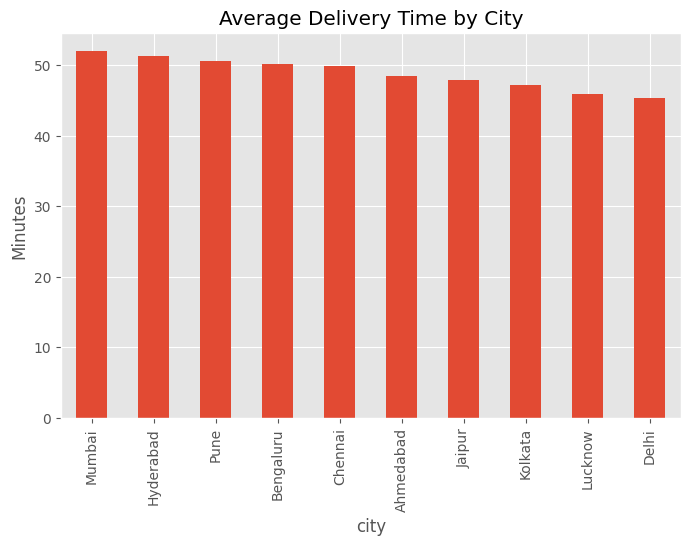

In [17]:
delivery_time = (
    df.groupby("city")["actual_delivery_time_min"]
      .mean()
      .sort_values(ascending=False)
)

delivery_time.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Average Delivery Time by City")
plt.ylabel("Minutes")
plt.show()

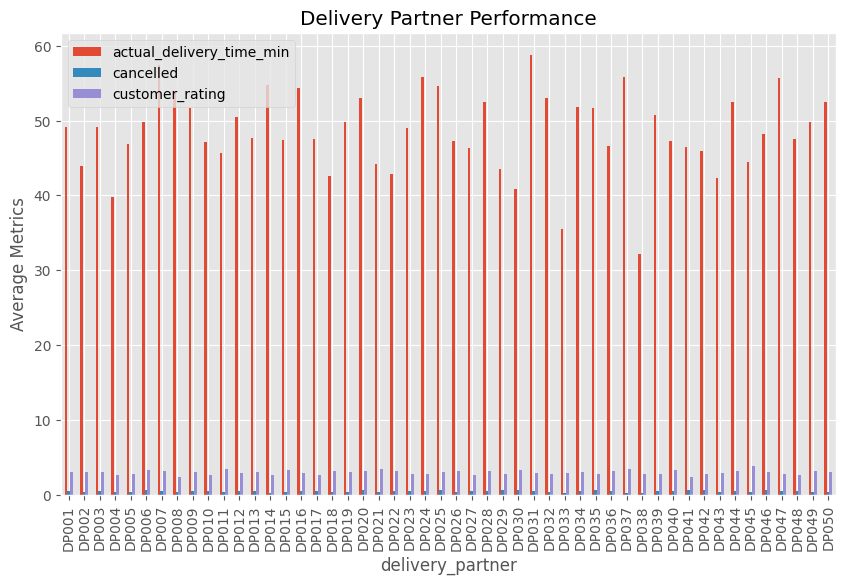

In [19]:
partner_perf = df.groupby("delivery_partner").agg({
    "actual_delivery_time_min": "mean",
    "cancelled": "mean",
    "customer_rating": "mean"
})

partner_perf.plot(kind="bar", figsize=(10,6))
plt.title("Delivery Partner Performance")
plt.ylabel("Average Metrics")
plt.show()


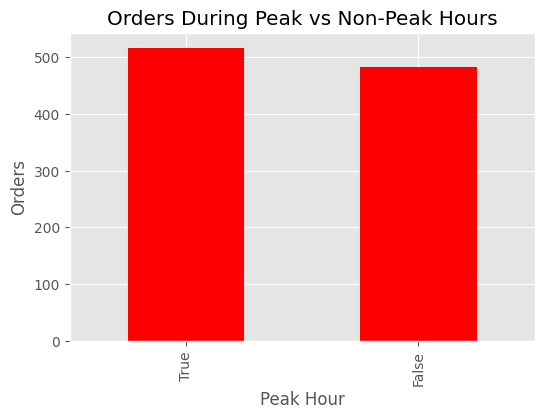

In [20]:
peak_orders = df["peak_hour"].value_counts()
peak_orders.plot(kind="bar", color="red", figsize=(6,4))
plt.title("Orders During Peak vs Non-Peak Hours")
plt.xlabel("Peak Hour")
plt.ylabel("Orders")
plt.show()


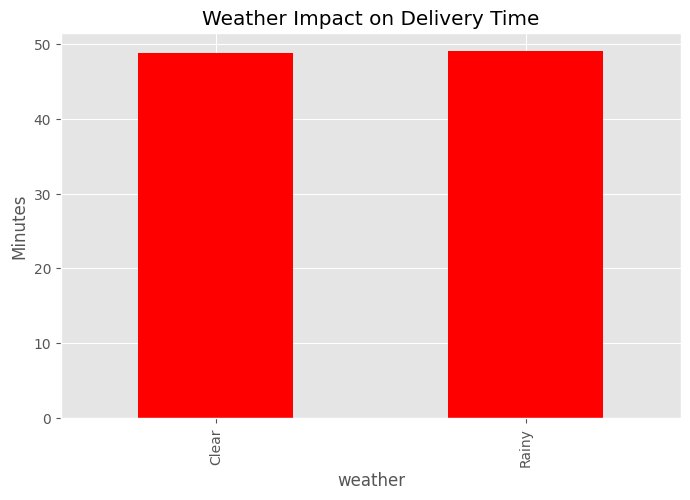

In [21]:
weather_perf = df.groupby("weather")["actual_delivery_time_min"].mean()
weather_perf.plot(kind="bar", figsize=(8,5), color="red")
plt.title("Weather Impact on Delivery Time")
plt.ylabel("Minutes")
plt.show()


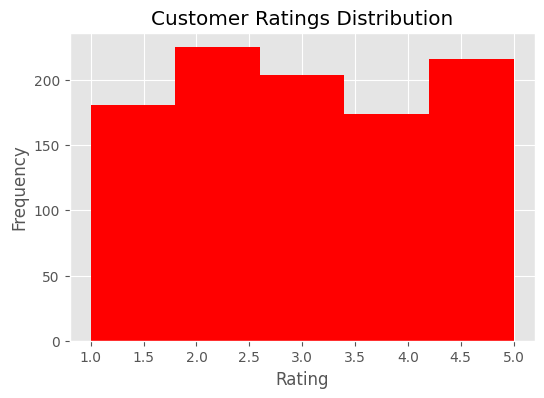

In [22]:
df["customer_rating"].plot(kind="hist", bins=5, color="red", figsize=(6,4))
plt.title("Customer Ratings Distribution")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.show()


# 📊 Executive Summary – Blinkit Delivery Analytics

### Key Insights
- **High cancellation rate (~48%)** indicates operational inefficiencies that need urgent attention.
- **Average delivery time (~49 minutes)** is significantly higher than the estimated ETA (~36 minutes), showing consistent delays.
- **Peak hours** drive more orders but also contribute to longer delivery times.
- **Weather conditions** (especially rainy days) increase delivery delays compared to clear weather.
- **Delivery partner performance** varies widely — some partners consistently deliver faster and achieve higher customer ratings.
- **Customer ratings** cluster around 3, suggesting moderate satisfaction but clear room for improvement.

---

### Recommendations
- **Optimize partner training & incentives**: Focus on underperforming delivery partners to reduce delays and cancellations.
- **Peak-hour staffing adjustments**: Increase rider availability during peak hours to balance demand and reduce late deliveries.
- **Weather contingency planning**: Introduce surge pricing, flexible scheduling, or backup riders during adverse weather conditions.
- **Customer experience initiatives**: Offer loyalty rewards or discounts to improve ratings and reduce cancellations.
- **Operational monitoring dashboard**: Implement real-time tracking of KPIs (delivery time, cancellations, ratings) for proactive management.

---
